In [33]:
#Importing required packags.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import svm
from sklearn.neural_network import MLPClassifier
#from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
%matplotlib inline


In [34]:
#Loading dataset
wine = pd.read_csv('winequality-red-practice.csv', sep=';')

In [35]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,9.1,0.70,0.54,2.7,0.063,19.0,11.0,0.9989,3.18,0.55,9.9,6
1,8.1,0.87,0.45,1.6,0.077,24.0,22.0,0.9955,3.31,0.51,9.9,6
2,9.4,0.28,0.28,1.5,0.060,11.0,30.0,0.9968,3.31,0.49,8.4,6
3,10.9,0.63,0.15,2.0,0.073,9.0,152.0,0.9968,3.38,0.73,10.0,4
4,7.9,0.41,0.40,1.9,0.038,7.0,60.0,0.9957,3.10,0.64,11.2,5


In [36]:
wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         500 non-null    float64
 1   volatile acidity      500 non-null    float64
 2   citric acid           500 non-null    float64
 3   residual sugar        500 non-null    float64
 4   chlorides             500 non-null    float64
 5   free sulfur dioxide   500 non-null    float64
 6   total sulfur dioxide  500 non-null    float64
 7   density               500 non-null    float64
 8   pH                    500 non-null    float64
 9   sulphates             500 non-null    float64
 10  alcohol               500 non-null    float64
 11  quality               500 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 47.0 KB


In [37]:
wine.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [38]:
#Preprocessing Data
bins = (2, 6.5, 8)
group_names = ['bad', 'good']
wine['quality'] = pd.cut(wine['quality'], bins = bins, labels = group_names)
wine['quality'].unique()

['bad', 'good']
Categories (2, str): ['bad' < 'good']

In [39]:
label_quality = LabelEncoder()
wine['quality'] = label_quality.fit_transform(wine['quality'])

In [40]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,9.1,0.70,0.54,2.7,0.063,19.0,11.0,0.9989,3.18,0.55,9.9,0
1,8.1,0.87,0.45,1.6,0.077,24.0,22.0,0.9955,3.31,0.51,9.9,0
2,9.4,0.28,0.28,1.5,0.060,11.0,30.0,0.9968,3.31,0.49,8.4,0
3,10.9,0.63,0.15,2.0,0.073,9.0,152.0,0.9968,3.38,0.73,10.0,0
4,7.9,0.41,0.40,1.9,0.038,7.0,60.0,0.9957,3.10,0.64,11.2,0


In [41]:
wine['quality'].value_counts()

quality
0    430
1     70
Name: count, dtype: int64

<Axes: ylabel='count'>

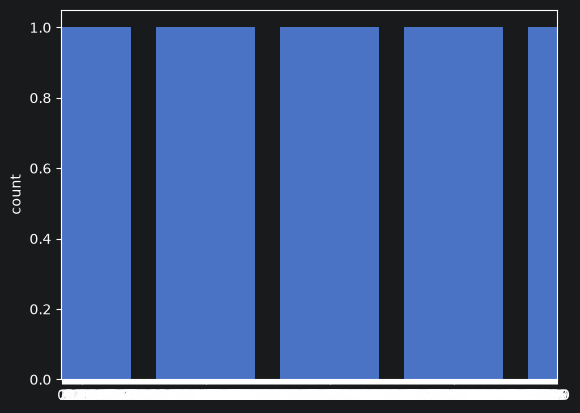

In [42]:
sns.countplot(wine['quality'])

In [43]:
#Now seperate the dataset as response variable and feature variabes
X = wine.drop('quality', axis = 1)
Y = wine['quality']

In [44]:
#Train and Test splitting of data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [45]:
#Applying standerd scaling to get optimized result

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [46]:
X_train[:10]

array([[ 0.41614843, -1.47341762, -1.56466049,  0.83721192,  0.87282107,
        -0.36012339, -1.04818016, -1.42514125,  0.02053712, -0.02654604,
         0.45794852],
       [ 0.71629154, -2.34828211, -0.69856231, -0.36309191, -0.31162109,
         0.58497901, -0.35235708,  0.70761957, -0.45470203,  1.16152829,
        -0.38792868],
       [-1.44473887,  0.80123007,  0.32992927,  2.14663428, -1.07304819,
        -0.67515753,  0.21460988, -2.13606152,  0.02053712, -0.91760178,
         0.36396216],
       [-0.84445265,  2.37598616, -0.15725095, -0.47221044,  0.30880099,
        -0.28136486, -0.97086648, -0.05408072,  1.31047197, -0.84334713,
         1.11585301],
       [ 0.05597669, -1.06514752, -0.31964436,  0.72809339, -1.21405321,
         1.37256434,  1.83819707,  1.01229969,  0.83523281,  0.49323648,
         0.26997581],
       [-0.84445265, -0.54022883, -0.10311981,  0.72809339, -0.56543013,
        -1.0689502 , -0.63584055,  0.60605953,  1.5820372 , -0.99185642,
         0.739

In [47]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [48]:
X_train


array([[ 0.41614843, -1.47341762, -1.56466049, ...,  0.02053712,
        -0.02654604,  0.45794852],
       [ 0.71629154, -2.34828211, -0.69856231, ..., -0.45470203,
         1.16152829, -0.38792868],
       [-1.44473887,  0.80123007,  0.32992927, ...,  0.02053712,
        -0.91760178,  0.36396216],
       ...,
       [-0.7243954 , -0.65687742, -1.51052935, ..., -0.86204988,
        -0.6205832 , -2.07968308],
       [ 0.05597669, -0.54022883,  0.16753587, ...,  0.7673415 ,
         0.49323648, -0.66988775],
       [-0.36422367,  0.91787867,  2.06212563, ...,  1.44625458,
         1.82982009,  0.26997581]], shape=(400, 11))

# Random Forest Classifer


In [49]:
rfc = RandomForestClassifier(n_estimators = 200)
rfc.fit(X_train, Y_train)
pred_rfc = rfc.predict(X_test)

In [50]:
X_test[:20]

array([[ 1.55669225, -1.59006622,  0.49232268,  0.61897486, -1.1294502 ,
         0.11242781, -1.02240893, -0.76500099, -0.72626726, -0.84334713,
         0.0820031 ],
       [ 1.61672088, -0.24860733, -1.40226708, -1.12692162,  0.02679095,
        -0.28136486,  1.94128197,  0.19981938, -0.04735419, -0.6205832 ,
        -1.60975131],
       [ 2.2170071 , -0.07363443,  1.412552  ,  1.27368604,  1.1266301 ,
        -0.28136486, -1.02240893, -0.71422098,  1.10679804, -0.69483784,
         0.45794852],
       [-0.7243954 ,  0.04301417,  0.92537177, -0.47221044, -0.67823414,
         0.42746194, -0.99663771,  0.35215944, -0.11524549,  2.57236654,
        -0.01198326],
       [-0.1841378 ,  0.39295997,  1.03363404, -0.58132897, -1.04484719,
        -0.596399  , -0.71315423,  0.75839959,  0.02053712, -1.06611107,
         0.36396216],
       [ 1.19652052,  1.44279736, -0.48203777, -0.36309191, -0.25521908,
         0.11242781,  2.81750362, -0.35876084,  0.97101543, -1.06611107,
        -1.515

In [51]:
#Let's see how our model performed
print(classification_report(Y_test, pred_rfc))
print(confusion_matrix(Y_test, pred_rfc))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        85
           1       0.00      0.00      0.00        15

    accuracy                           0.85       100
   macro avg       0.42      0.50      0.46       100
weighted avg       0.72      0.85      0.78       100

[[85  0]
 [15  0]]


C:\Users\adity\Downloads\python_practice\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\adity\Downloads\python_practice\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\adity\Downloads\python_practice\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

# SVM Classifier


In [52]:
clf = svm.SVC()
clf.fit(X_train, Y_train)
pred_clf = clf.predict(X_test)

In [53]:
#let's see how our model performed
print(classification_report(Y_test, pred_clf))
print(confusion_matrix(Y_test, pred_clf))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        85
           1       0.00      0.00      0.00        15

    accuracy                           0.85       100
   macro avg       0.42      0.50      0.46       100
weighted avg       0.72      0.85      0.78       100

[[85  0]
 [15  0]]


C:\Users\adity\Downloads\python_practice\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\adity\Downloads\python_practice\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\adity\Downloads\python_practice\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

# Neural Network

In [54]:
mlpc=MLPClassifier(hidden_layer_sizes = (10,10,10), max_iter = 500)
mlpc.fit(X_train, Y_train)
pred_mlpc = mlpc.predict(X_test)

C:\Users\adity\Downloads\python_practice\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [55]:
#Let's see how our model performed
print(classification_report(Y_test, pred_mlpc))
print(confusion_matrix(Y_test, pred_mlpc))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89        85
           1       0.17      0.07      0.10        15

    accuracy                           0.81       100
   macro avg       0.51      0.50      0.49       100
weighted avg       0.75      0.81      0.77       100

[[80  5]
 [14  1]]


In [56]:
from  sklearn.metrics import accuracy_score
cm = accuracy_score(Y_test, pred_mlpc)
cm

0.81

In [57]:
wine.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,9.1,0.70,0.54,2.7,0.063,19.0,11.0,0.9989,3.18,0.55,9.9,0
1,8.1,0.87,0.45,1.6,0.077,24.0,22.0,0.9955,3.31,0.51,9.9,0
2,9.4,0.28,0.28,1.5,0.060,11.0,30.0,0.9968,3.31,0.49,8.4,0
3,10.9,0.63,0.15,2.0,0.073,9.0,152.0,0.9968,3.38,0.73,10.0,0
4,7.9,0.41,0.40,1.9,0.038,7.0,60.0,0.9957,3.10,0.64,11.2,0
5,7.9,0.44,0.34,1.7,0.089,8.0,16.0,0.9941,3.40,0.72,9.0,0
6,11.0,0.42,0.44,2.7,0.082,79.0,57.0,0.9973,2.90,0.77,11.6,1
7,9.6,0.37,0.39,3.0,0.059,28.0,14.0,0.9966,3.22,0.71,10.9,0
8,7.5,0.54,0.47,2.1,0.107,6.0,86.0,0.9977,3.24,0.76,9.6,0
9,9.2,0.38,0.17,3.6,0.119,6.0,29.0,0.9957,3.40,0.66,10.2,0


In [58]:
Xnew = [[7.3,0.58,0.00,2.0,0.065,15.0,21.0,0.9946,3.36,0.47,10.0]]
Xnew = sc.transform(Xnew)
Ynew = rfc.predict(Xnew)
Ynew

array([0])